In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df=pd.read_csv(r'C:\Users\Shasaank\Work\house price predictor\data\raw\Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


DIsplaying first 10 rows

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
df.shape

(545, 13)

In [5]:
r,c=df.shape
print(f'Rows: {r}, Columns: {c}',sep='\n')


Rows: 545, Columns: 13


Target : price

Features : 
-area
-bedrooms
-bathrooms
-stories
-mainroad
-guestroom
-basement
-hotwaterheating
-airconditioning
-parking
-prefarea
-furnishingstatus

In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [9]:
boolean_cols=['mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning','prefarea']
for col in boolean_cols:
    df[col]=[1 if value=='yes' else 0 for value in df[col]]

In [10]:
df['furnishingstatus'].unique()

<ArrowStringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

In [11]:
df=pd.get_dummies(df,columns=['furnishingstatus'],dtype=int,drop_first=True)

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


Train Test Split


In [13]:
X=df.drop('price',axis=1)
Y=df['price']

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


Linear Regression Model Training


In [14]:
LR_model=LinearRegression()
LR_model.fit(X_train,Y_train)
Y_pred_LR=LR_model.predict(X_test)

Randon Forest Model Training

In [15]:
RF_model=RandomForestRegressor(n_estimators=100,random_state=42)
RF_model.fit(X_train,Y_train)
Y_pred_RF=RF_model.predict(X_test)

Metrics

In [16]:
def evaluate_model(y_true, y_pred):
    mae= mean_absolute_error(y_true,y_pred)

    mse= mean_squared_error(y_true,y_pred)
    rmse= np.sqrt(mse)

    r2= r2_score(y_true,y_pred)

    return mae,rmse,r2


In [17]:
LR_MAE, LR_RMSE, LR_R2 = evaluate_model(Y_test, Y_pred_LR)
print(f"Linear Regression Model Evaluation:\nLR_MAE: {LR_MAE}\nLR_RMSE: {LR_RMSE}\nLR_R2 Score: {LR_R2}")

Linear Regression Model Evaluation:
LR_MAE: 970043.4039201637
LR_RMSE: 1324506.9600914384
LR_R2 Score: 0.6529242642153186


In [18]:
RF_MAE, RF_RMSE, RF_R2 = evaluate_model(Y_test, Y_pred_RF)
print(f"Random Forest Model Evaluation:\nRF_MAE: {RF_MAE}\nRF_RMSE: {RF_RMSE}\nRF_R2 Score: {RF_R2}")

Random Forest Model Evaluation:
RF_MAE: 1022560.0527522935
RF_RMSE: 1401496.8425384816
RF_R2 Score: 0.6114024924156645


Comparision

In [19]:
comp_df=pd.DataFrame()
comp_df=comp_df.assign(
    model=['Linear Regression','Random Forest'],
    MAE=[LR_MAE,RF_MAE],
    RMSE=[LR_RMSE,RF_RMSE],
    R2=[LR_R2,RF_R2]
)

comp_df.to_csv(r'C:\Users\Shasaank\Work\house price predictor\data\processed\model_comparison.csv',index=False)
comp_df.head()

,model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


Visualization

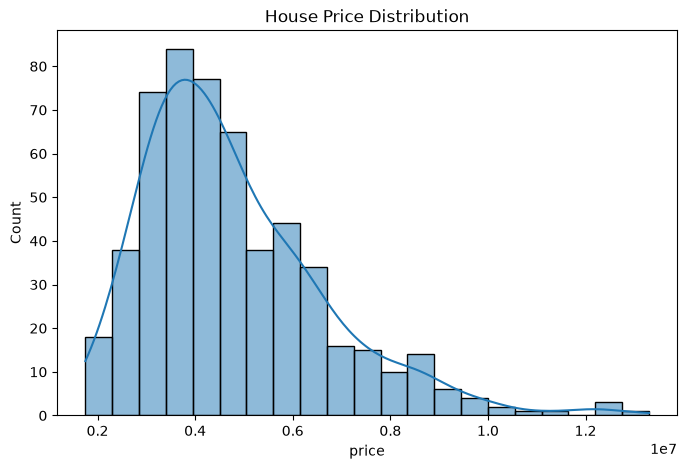

In [20]:
#histogram

plt.figure(figsize=(8,5))

sns.histplot(df['price'],kde=True)

plt.title("House Price Distribution")

plt.savefig(r"C:\Users\Shasaank\Work\house price predictor\charts\price_distribution.png")

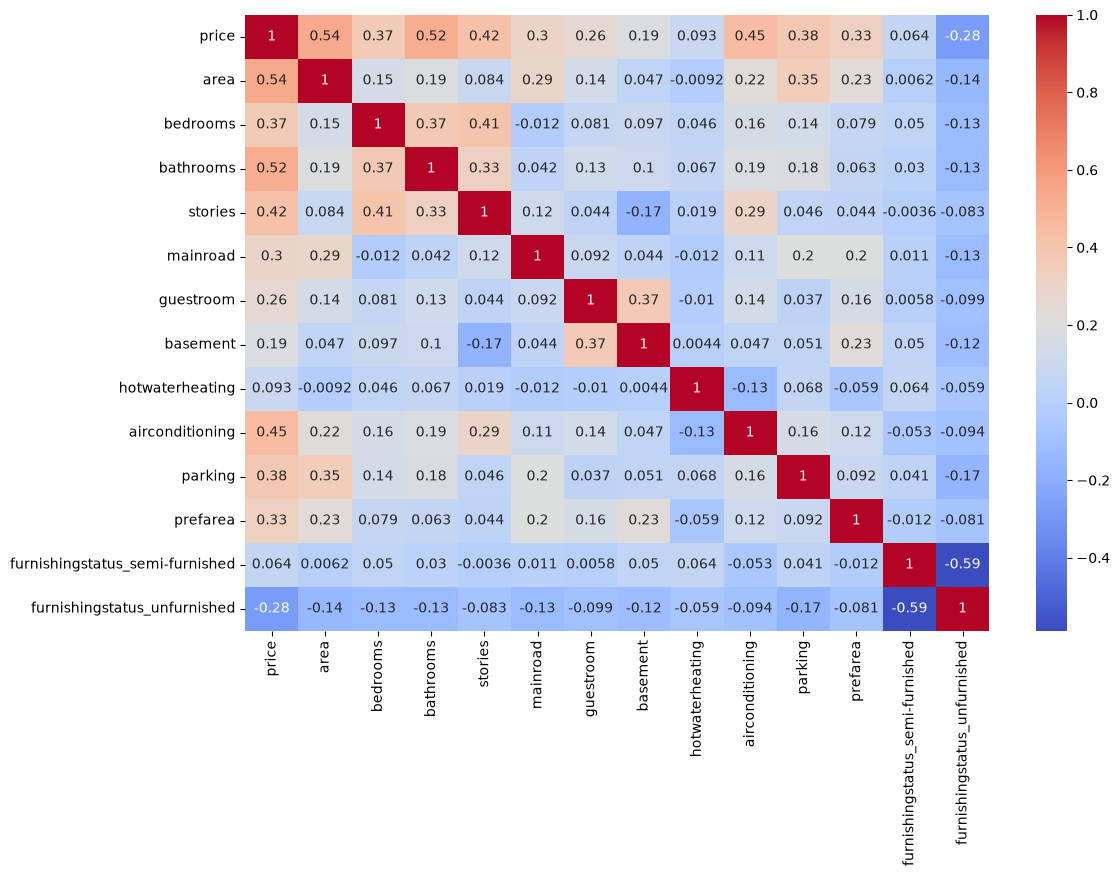

In [21]:
#correlation heatmap
plt.figure(figsize=(12,8))


sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.savefig(r"C:\Users\Shasaank\Work\house price predictor\charts\correlation_heatmap.png")

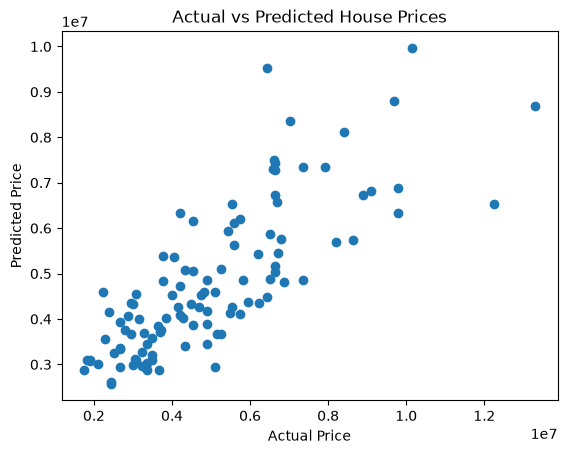

In [22]:
#actual vs predicted plot
plt.scatter(
    Y_test,
    Y_pred_RF
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
"Actual vs Predicted House Prices"
)

plt.savefig(r"C:\Users\Shasaank\Work\house price predictor\charts\actual_vs_predicted.png")

Insights

-The analysis shows that area, number of bedrooms, and number of bathrooms are among the most influential factors affecting house prices.
-The Linear Regression model achieved an R2 score of 0.65, meaning it was able to explain around 65% of the variation in house prices from the available features.
-The Random Forest Regression model achieved an R2 score of 0.61, meaning it underperformed in comparion to linear regression most likely due to the small size of the dataset
-A suprising insight in the analysis was that amenities and furnish states had much lesser impact on the house prices than expected, which could provide insights to real estate buisenesses on where to focus their pricing.
-Based on my findings and the insights gained from the analysis, i would recommend real estate buisenesses to focus and focus less on amenities such as hot water heating and basement and shift them to more contributing factors like stories.

